In [3]:
roi = '/gpfs/data1/vclgp/decontot/data/vector/other_boundaries/RO_UF_2022.shp'
h3db = '/gpfs/data1/vclgp/data/iss_gedi/h3_mock/database_world_merged'

## H3 workflow

In [ ]:
roi = 'https://hub.arcgis.com/api/v3/datasets/2315ef0b071a4ec59420e3d342dbcfe2_0/downloads/data?format=shp&spatialRefId=3857&where=1=1'
root_path = '/gpfs/data1/vclgp/decontot/repos/gedih3/tmp/h3_test/'
# root_path = '/gpfs/data1/vclgp/decontot/repos/gedih3/tmp/egi_test/'

In [ ]:
# h3db = 's3://database_world_merged'
h3db = 'http://localhost:7000/database_world_merged'
opath = root_path + '01_extracted'

# -vv --s3-anon --s3-endpoint http://localhost:7000
# -d $h3db
# -egi
!gh3_extract --output "$opath" --region "$roi" --geo --time --quality -l2a rh_098 land_cover_data/pft_class_l2a -l4a agbd land_cover_data/leaf_off_flag_l4a -l4c wsci -l2b fhd_normal


                     GEDI EGI Data Extraction Tool                    
                             gedih3 v0.0.1                            

Database: /gpfs/data1/vclgp/data/iss_gedi/h3_mock/database_world_merged
Parsing region: https://hub.arcgis.com/api/v3/datasets/2315ef0b071a4ec59420e3d342dbcfe2_0/downloads/data?format=shp&spatialRefId=3857&where=1=1
  Total variables: 8
Query filter: `agbd_prediction/l2_quality_flag_a10_l4a` == 1 & `agbd_prediction/l2_quality_flag_a1_l4a` == 1 & `agbd_prediction/l2_quality_flag_a2_l4a` == 1 & `agbd_prediction/l2_quality_flag_a5_l4a` == 1 & `agbd_prediction/l4_quality_flag_a10_l4a` == 1 & `agbd_prediction/l4_quality_flag_a1_l4a` == 1 & `agbd_prediction/l4_quality_flag_a2_l4a` == 1 & `agbd_prediction/l4_quality_flag_a5_l4a` == 1 & `geolocation/quality_flag_a10_l2a` == 1 & `geolocation/quality_flag_a1_l2a` == 1 & `geolocation/quality_flag_a2_l2a` == 1 & `geolocation/quality_flag_a5_l2a` == 1 & `l2_quality_flag_l4a` == 1 & `l2b_quality_flag_l2b` ==

In [2]:
img = '/gpfs/data1/vclgp/decontot/data/raster/nasa_dem.vrt'
ipath = root_path + '01_extracted'
opath = root_path + '06_image'

!gh3_from_img --image "$img" --database $ipath --output $opath --window 031


                       GEDI Raster Sampling Tool                      
                             gedih3 v0.0.1                            

Image source: /gpfs/data1/vclgp/decontot/data/raster/nasa_dem.vrt
  CRS: EPSG:4326
  Bounds (WGS84): (-179.000729, -60.76159707157174, 179.00072892984596, 65.825669)
  Bands: 1 ['b0']
  Resolution: (0.00026949458523585647, -0.00026949458523585647)
Window operations: ['b0_mean_3x3']
Database: /gpfs/data1/vclgp/decontot/repos/gedih3/tmp/egi_test/01_extracted
Dask dashboard: http://127.0.0.1:8787/status
Loading GEDI data from simplified dataset...
  ROI: entire dataset (all tiles)
  Loaded 6 partitions
  Partition column: egi12
Sampling raster at GEDI shot locations...
Exporting data...
[########################################] | 100% Completed |  8.3s
 SUCCESS: Raster sampling complete → /gpfs/data1/vclgp/decontot/repos/gedih3/tmp/egi_test/06_image



In [3]:
poly = '/gpfs/data1/vclgp/decontot/data/vector/wwf_ecoregions/wwf_terr_ecos.shp'
ipath = root_path + '01_extracted'
opath = root_path + '07_polygon'

!gh3_from_polygon -i $poly -d $ipath -o $opath


                     GEDI Vector Polygon Join Tool                    
                             gedih3 v0.0.1                            

Vector source: /gpfs/data1/vclgp/decontot/data/vector/wwf_ecoregions/wwf_terr_ecos.shp
  CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
  Bounds (WGS84): (-179.99998860061166, -89.89197327740294, 179.9999886006118, 83.6231251716938)
  Features: 14458
  Geometry type: Polygon
  Columns: ['OBJECTID', 'AREA', 'PERIMETER', 'ECO_NAME', 'REALM', 'BIOME', 'ECO_NUM', 'ECO_ID', 'ECO_SYM', 'GBL_STAT', 'G200_REGIO', 'G200_NUM', 'G200_BIOME', 'G200_STAT', 'Shape_Leng', 'Shape_Area', 'area_km2', 'eco_code', 'PER_area', 'PER_area_1', 'PER_area_2']
  Join predicate: within
  Join type: left
Database: /g

In [10]:
upath = root_path + '01_extracted'
!gh3_update -d $upath -l2a rh_098 rh_095 -l2b cover_z_000


                       GEDI Dataset Update Tool                       
                             gedih3 v0.0.1                            

  Target dataset: /gpfs/data1/vclgp/decontot/repos/gedih3/tmp/egi_test/01_extracted
  Index type: egi
Mode: Add columns from H3 database
  Source database: /gpfs/data1/vclgp/data/iss_gedi/h3_mock/database_world_merged
  New columns to add: ['cover_z_000_l2b', 'rh_095_l2a']
  Dask dashboard: http://127.0.0.1:8787/status
  Updated 6/6 partition files.
  Metadata updated.

                 SUCCESS: Dataset updated successfully                



In [4]:
upath = root_path + '01_extracted'
mpath = root_path + '06_image'
!gh3_update -d $upath -m $mpath


                       GEDI Dataset Update Tool                       
                             gedih3 v0.0.1                            

  Target dataset: /gpfs/data1/vclgp/decontot/repos/gedih3/tmp/egi_test/01_extracted
  Index type: egi
Mode: Merge columns from another dataset
  New columns to merge: ['b0', 'relative_pixel_distance', 'b0_mean_3x3']
  Updated 6/6 files (0 with no matching merge partition).
  Metadata updated.

                 SUCCESS: Dataset updated successfully                



In [ ]:
ipath = root_path + '01_extracted'
opath = root_path + '02_aggregated'
!gh3_aggregate -d $ipath -o $opath -h3 8 -a "['mean','median','std','p75','count']" -l fhd_normal_l2b wsci_l4c agbd_l4a rh_098_l2a


                    GEDI EGI Data Aggregation Tool                    
                             gedih3 v0.0.1                            

Database: /gpfs/data1/vclgp/decontot/repos/gedih3/tmp/egi_test/01_extracted
  Source: simplified_dataset (egi index)
  Total variables: 5
Aggregation: ['mean', 'median', 'std', <function _make_percentile_func.<locals>.percentile_func at 0x14757a4c2520>, 'count']
Dask dashboard: http://127.0.0.1:8787/status
  Target: EGI level 6 (~1001m pixels)
  Partition: EGI level 12 (~160143m)
Loading data...
  Source: simplified_dataset (EGI index)
  Loaded 6 partitions
Aggregating to EGI...
  Result: 6 EGI partitions
Exporting data...########################] | 100% Completed |  5.9s
[########################################] | 100% Completed |  0.1s
 SUCCESS: Data exported to /gpfs/data1/vclgp/decontot/repos/gedih3/tmp/egi_test/02_aggregated



<Axes: >

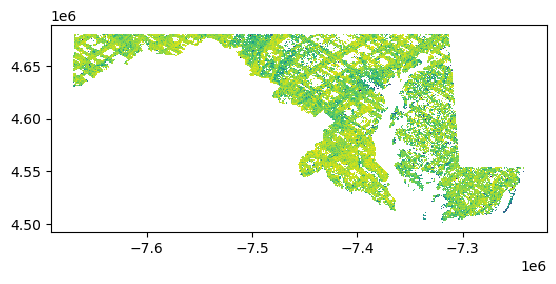

In [13]:
import dask_geopandas

gdf = dask_geopandas.read_parquet(root_path + '02_aggregated').compute()
gdf.plot(column='fhd_normal_l2b_mean')

In [14]:
ipath = root_path + '02_aggregated'
opath = root_path + '03_rasterized'
!gh3_rasterize -d $ipath -o $opath


                        GEDI Rasterization Tool                       
                             gedih3 v0.0.1                            

Dask dashboard: http://127.0.0.1:8787/status
Dataset type: EGI level 6 (~1001m)
Input: /gpfs/data1/vclgp/decontot/repos/gedih3/tmp/egi_test/02_aggregated
Loading dataset...
  Loaded 6 partitions
Rasterizing...
Exported 6 raster files to /gpfs/data1/vclgp/decontot/repos/gedih3/tmp/egi_test/03_rasterized

                    SUCCESS: Rasterization complete                   



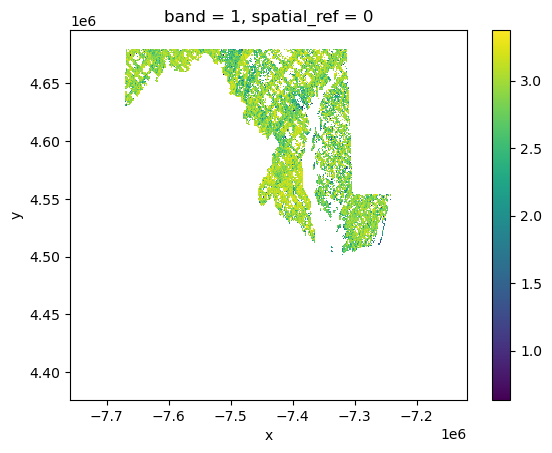

In [15]:
import rioxarray

rimg = rioxarray.open_rasterio(root_path + '03_rasterized/mosaic.vrt').compute()
rimg[0].plot()

In [5]:
ipath = root_path + '01_extracted'
opath = root_path + '04_egi_timeseries_merged_rasterized'
!gh3_aggregate -d $ipath -o $opath -m -R -egi 6 -t0 2020-01-01 -t1 2023-01-01 -a "['mean','std']" -tu years -ti 1 -l rh_098_l2a agbd_l4a wsci_l4c


                    GEDI EGI Data Aggregation Tool                    
                             gedih3 v0.0.1                            

Database: /gpfs/data1/vclgp/decontot/repos/gedih3/tmp/egi_test/01_extracted
  Source: simplified_dataset (egi index)
  Total variables: 5
Query filter: datetime >= '2020-01-01' & datetime <= '2023-01-01'
Aggregation: ['mean', 'std']
Dask dashboard: http://127.0.0.1:8787/status
  Target: EGI level 6 (~1001m pixels)
  Partition: EGI level 12 (~160143m)
Time-series mode: 1 years from 2020-01-01 to 2023-01-01
Loading data...
  Source: simplified_dataset (EGI index)
  Loaded 6 partitions
── Window: 2020-01-01-to-2021-01-01 ──###] | 100% Completed |  2.3s
Aggregating to EGI...
  Result: 6 EGI partitions
Rasterizing aggregated data to GeoTIFF...] | 100% Completed |  0.6s
[########################################] | 100% Completed |  0.2s
 SUCCESS: Merged raster exported to /gpfs/data1/vclgp/decontot/repos/gedih3/tmp/egi_test/04_egi_timeseries_merged_r

In [13]:
opath = root_path + '05_single_pass_egi_aggregated_rasterized'
!gh3_aggregate -o $opath -m -R -egi 8 -t0 2020-01-01 -t1 2023-01-01 -a "['mean','std']" -l wsci_l4c rh_098_l2a -r "$roi" -q "wsci_quality_flag_l4c == 1"


                    GEDI EGI Data Aggregation Tool                    
                             gedih3 v0.0.1                            

Database: /gpfs/data1/vclgp/data/iss_gedi/h3_mock/database_world_merged
Parsing region: https://hub.arcgis.com/api/v3/datasets/2315ef0b071a4ec59420e3d342dbcfe2_0/downloads/data?format=shp&spatialRefId=3857&where=1=1
  Total variables: 4
Query filter: datetime >= '2020-01-01' & datetime <= '2023-01-01' & (wsci_quality_flag_l4c == 1)
Aggregation: ['mean', 'std']
Dask dashboard: http://127.0.0.1:8787/status
  Target: EGI level 8 (~10009m pixels)
  Partition: EGI level 12 (~160143m)
Loading data into EGI partitions (no shuffle)...
  Loaded 6 EGI tiles
Aggregating to EGI...
  Result: 6 EGI partitions
Rasterizing aggregated data to GeoTIFF...] | 100% Completed |  4min 49.3s
[########################################] | 100% Completed |  0.1s
 SUCCESS: Merged raster exported to /gpfs/data1/vclgp/decontot/repos/gedih3/tmp/h3_test/05_single_pass_egi_aggr

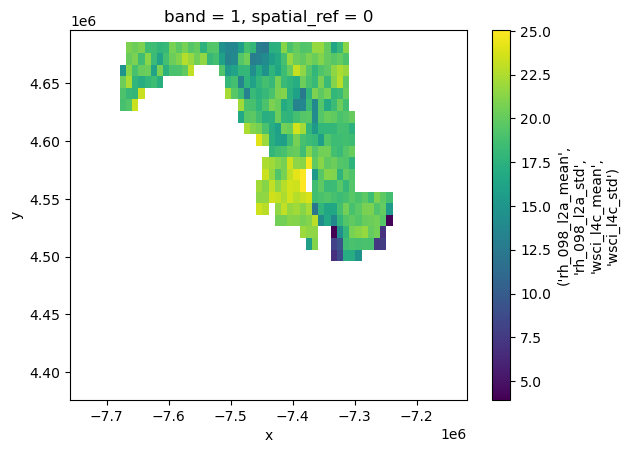

In [14]:
import rioxarray
rimg = rioxarray.open_rasterio(root_path + '05_single_pass_egi_aggregated_rasterized.tif').compute()
rimg[0].plot()

## Python API

In [40]:
import gedih3.gh3driver as gh3
from gedih3.config import GH3_DEFAULT_H3_DIR

bbox = [-51,0,-50,1]

ddf = gh3.gh3_load(
    source=GH3_DEFAULT_H3_DIR,
    columns=['agbd_l4a', 'rh_098_l2a'],
    region=bbox,
    query='quality_flag_l2a == 1 and agbd_l4a > 0',
)

ddf.head()

# agg_df = gh3.gh3_aggregate(ddf, target_res=8, agg=['mean', 'std','count'])
# agg_df

,agbd_l4a,rh_098_l2a,h3_03,shot_number
h3_12,,,,
8c80418f62159ff,3.602715,7.810000,838041fffffffff,62391100200099036
8c80418f0c805ff,91.971184,17.770000,838041fffffffff,62390800200100571
8c80418f6210bff,74.064415,20.680000,838041fffffffff,62391100200099037
8c80418f01345ff,0.318554,6.060000,838041fffffffff,62390600200236972
8c80418f0c9c9ff,131.556183,23.120001,838041fffffffff,62390800200100572


In [39]:
import gedih3.gh3driver as gh3
from gedih3.config import GH3_DEFAULT_H3_DIR

bbox = [-51,0,-50,1]

ddf = gh3.egi_load(
    source=GH3_DEFAULT_H3_DIR,
    columns=['agbd_l4a', 'rh_098_l2a'],
    region=bbox,
    query='quality_flag_l2a == 1 and agbd_l4a > 0',
    partition_level=7
)

ddf.head()
# agg_df = gh3.egi_aggregate(ddf, target_level=6, agg=['mean', 'std','count'], repartition=True)
# agg_df

# df = agg_df.partitions[0].compute()
# df.plot(column='agbd_l4a_mean')


,agbd_l4a,rh_098_l2a,shot_number,geometry,egi07
egi01,,,,,
1077045134476108007,211.222122,24.490000,61780600200238465,POINT (-50.80418 5.65559e-5),7077045000067000054
1077045135271108019,222.449127,22.959999,61780800200097875,POINT (-50.79594 0.00015),7077045000067000054
1077045134505108061,173.334717,22.730000,61780600200238466,POINT (-50.80389 0.00048),7077045000067000054
1077045135300108073,374.178467,16.400000,61780800200097876,POINT (-50.79564 0.00057),7077045000067000054
1077045134534108114,245.428268,28.680000,61780600200238467,POINT (-50.80359 0.0009),7077045000067000054


## EGI workflow

In [10]:
opath = '/gpfs/data1/vclgp/decontot/repos/gedih3/tmp/egi_tests/01_extracted'
!gh3_extract -d $h3db -r $roi -o $opath -l2a rh_098 -l4a agbd -l4c wsci -l2b fhd_normal -g -t -q "wsci_quality_flag_l4c == 1" -egi

usage: gh3_extract [-h] [-d DATABASE] -o OUTPUT [-f FORMAT] [-m] [-egi [EGI]]
                   [--egi-shuffle] [-r REGION] [-t0 TIME_START] [-t1 TIME_END]
                   [-l LIST [LIST ...]]
                   [--detail-level {minimal,min,default,def,all}]
                   [-l1b [L1B ...]] [-l2a [L2A ...]] [-l2b [L2B ...]]
                   [-l4a [L4A ...]] [-l4c [L4C ...]] [-g] [-t] [-q QUERY] [-y]
                   [-s DASK_SCHEDULER] [-N CORES] [-T THREADS] [-M MEMORY]
                   [-P PORT] [--s3-endpoint S3_ENDPOINT] [--s3-key S3_KEY]
                   [--s3-secret S3_SECRET] [--s3-anon]
                   [--remote-user REMOTE_USER] [--remote-pass REMOTE_PASS]
                   [--remote-token REMOTE_TOKEN] [--ssh-key SSH_KEY] [-v] [-Q]
gh3_extract: error: argument -d/--database: expected one argument


In [18]:
img = '/gpfs/data1/vclgp/decontot/data/raster/nasa_dem'
ipath = '/gpfs/data1/vclgp/decontot/repos/gedih3/tmp/egi_tests/01_extracted'
opath = '/gpfs/data1/vclgp/decontot/repos/gedih3/tmp/egi_tests/06_image'

!gh3_from_img -i $img -d $ipath -o $opath -vv -B 0 1 -w 031 -g

2026-02-11 16:47:48 [INFO] gedih3.cli.gh3_from_img: 
2026-02-11 16:47:48 [INFO] gedih3.cli.gh3_from_img: ======================================================================
2026-02-11 16:47:48 [INFO] gedih3.cli.gh3_from_img:                        GEDI Raster Sampling Tool                      
2026-02-11 16:47:48 [INFO] gedih3.cli.gh3_from_img:                              gedih3 v0.0.1                            
2026-02-11 16:47:48 [INFO] gedih3.cli.gh3_from_img: ======================================================================
2026-02-11 16:47:48 [INFO] gedih3.cli.gh3_from_img: 
2026-02-11 16:47:48 [INFO] gedih3.cli.gh3_from_img: Image source: /gpfs/data1/vclgp/decontot/data/raster/nasa_dem
2026-02-11 16:49:32 [INFO] gedih3.imgutils: Built VRT mosaic from 3774 tiles: /gpfs/data1/vclgp/decontot/repos/gedih3/tmp/egi_tests/06_image/nasa_dem.vrt
2026-02-11 16:49:32 [INFO] gedih3.cli.gh3_from_img:   Built VRT mosaic from 3774 tiles
2026-02-11 16:49:32 [INFO] gedih3.cli.gh3_from_

In [4]:
poly = '/gpfs/data1/vclgp/decontot/data/vector/wwf_ecoregions/wwf_terr_ecos.shp'
ipath = '/gpfs/data1/vclgp/decontot/repos/gedih3/tmp/egi_tests/01_extracted'
opath = '/gpfs/data1/vclgp/decontot/repos/gedih3/tmp/egi_tests/07_polygon'

!gh3_from_polygon -i $poly -d $ipath -o $opath -vv

2026-02-12 10:49:07 [INFO] gedih3.cli.gh3_from_polygon: 
2026-02-12 10:49:07 [INFO] gedih3.cli.gh3_from_polygon: ======================================================================
2026-02-12 10:49:07 [INFO] gedih3.cli.gh3_from_polygon:                      GEDI Vector Polygon Join Tool                    
2026-02-12 10:49:07 [INFO] gedih3.cli.gh3_from_polygon:                              gedih3 v0.0.1                            
2026-02-12 10:49:07 [INFO] gedih3.cli.gh3_from_polygon: ======================================================================
2026-02-12 10:49:07 [INFO] gedih3.cli.gh3_from_polygon: 
2026-02-12 10:49:07 [INFO] gedih3.cli.gh3_from_polygon: Vector source: /gpfs/data1/vclgp/decontot/data/vector/wwf_ecoregions/wwf_terr_ecos.shp
2026-02-12 10:49:07 [INFO] gedih3.cli.gh3_from_polygon:   CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],

In [ ]:
!gh3_update -d $opath -l2a rh_098 rh_095 -l2b cover_z_000

In [17]:
aopath = '/gpfs/data1/vclgp/decontot/repos/gedih3/tmp/egi_tests/01_extracted_append'
# !gh3_extract -d $h3db -r $roi -o $aopath -l4c wsci_xy wsci_z -g -t -q "wsci_quality_flag_l4c == 1" -egi -Q
!gh3_update -d $opath -m $aopath -vv

2026-02-10 18:23:35 [INFO] gedih3.cli.gh3_update: 
2026-02-10 18:23:35 [INFO] gedih3.cli.gh3_update: ======================================================================
2026-02-10 18:23:35 [INFO] gedih3.cli.gh3_update:                        GEDI Dataset Update Tool                       
2026-02-10 18:23:35 [INFO] gedih3.cli.gh3_update:                              gedih3 v0.0.1                            
2026-02-10 18:23:35 [INFO] gedih3.cli.gh3_update: ======================================================================
2026-02-10 18:23:35 [INFO] gedih3.cli.gh3_update: 
2026-02-10 18:23:35 [INFO] gedih3.cli.gh3_update:   Target dataset: /gpfs/data1/vclgp/decontot/repos/gedih3/tmp/egi_tests/01_extracted
2026-02-10 18:23:35 [INFO] gedih3.cli.gh3_update:   Index type: egi
2026-02-10 18:23:35 [INFO] gedih3.cli.gh3_update: Mode: Merge columns from another dataset
2026-02-10 18:23:35 [INFO] gedih3.cli.gh3_update:   New columns to merge: ['wsci_xy_l4c', 'wsci_z_l4c']
2026-02-10 18:23

In [18]:
ipath = '/gpfs/data1/vclgp/decontot/repos/gedih3/tmp/egi_tests/01_extracted'
opath = '/gpfs/data1/vclgp/decontot/repos/gedih3/tmp/egi_tests/02_aggregated'
!gh3_aggregate -d $ipath -o $opath -egi 8 -a "['mean','median','std','p75','count']" -l fhd_normal_l2b wsci_l4c


                    GEDI EGI Data Aggregation Tool                    
                             gedih3 v0.0.1                            

Database: /gpfs/data1/vclgp/decontot/repos/gedih3/tmp/egi_tests/01_extracted
  Source: simplified_dataset (egi index)
  Total variables: 3
Aggregation: ['mean', 'median', 'std', <function _make_percentile_func.<locals>.percentile_func at 0x1543155e4ae0>, 'count']
Dask dashboard: http://127.0.0.1:8787/status
  Target: EGI level 8 (~10009m pixels)
  Partition: EGI level 12 (~160143m)
Loading data...
  Source: simplified dataset (format: parquet)
  Loaded 19 partitions
Aggregating to EGI (shuffle-based)...
  Result: 19 EGI partitions
  Dropping internal columns: ['egi12']
Exporting data...########################] | 100% Completed |  1.5s
  Output format: simplified flat files
Writing dataset metadata...##############] | 100% Completed |  0.1s

 SUCCESS: 19 files exported to /gpfs/data1/vclgp/decontot/repos/gedih3/tmp/egi_tests/02_aggregated



In [19]:
ipath = '/gpfs/data1/vclgp/decontot/repos/gedih3/tmp/egi_tests/02_aggregated'
opath = '/gpfs/data1/vclgp/decontot/repos/gedih3/tmp/egi_tests/03_rasterized'
!gh3_rasterize -d $ipath -o $opath -Q

In [20]:
ipath = '/gpfs/data1/vclgp/decontot/repos/gedih3/tmp/egi_tests/01_extracted'
opath = '/gpfs/data1/vclgp/decontot/repos/gedih3/tmp/egi_tests/04_egi_timeseries_merged_rasterized'
!gh3_aggregate -d $ipath -o $opath -m -R -egi 6 -t0 2020-01-01 -t1 2022-01-01 -a "['mean','std']" -tu months -ti 6 -l fhd_normal_l2b wsci_l4c


                    GEDI EGI Data Aggregation Tool                    
                             gedih3 v0.0.1                            

Database: /gpfs/data1/vclgp/decontot/repos/gedih3/tmp/egi_tests/01_extracted
  Source: simplified_dataset (egi index)
  Total variables: 4
Query filter: datetime >= '2020-01-01' & datetime <= '2022-01-01'
Aggregation: ['mean', 'std']
Dask dashboard: http://127.0.0.1:8787/status
  Target: EGI level 6 (~1001m pixels)
  Partition: EGI level 12 (~160143m)
Time-series mode: 6 months from 2020-01-01 to 2022-01-01
Loading data...
  Source: simplified dataset (format: parquet)
  Loaded 19 partitions
── Window: 2020-01-01-to-2020-07-01 ──###] | 100% Completed |  8.1s
Aggregating to EGI (shuffle-based)...
  Result: 19 EGI partitions
Rasterizing aggregated data to GeoTIFF...] | 100% Completed | 17.1s
[########################################] | 100% Completed |  0.2s
 SUCCESS: Merged raster exported to /gpfs/data1/vclgp/decontot/repos/gedih3/tmp/egi_tests

## Plot results

In [10]:
import rioxarray
img_03 = rioxarray.open_rasterio("/gpfs/data1/vclgp/decontot/repos/gedih3/tmp/h3_tests/05_single_pass_egi_aggregated_rasterized.tif")
img_05 = rioxarray.open_rasterio("/gpfs/data1/vclgp/decontot/repos/gedih3/tmp/h3_tests/03_rasterized/mosaic.vrt")

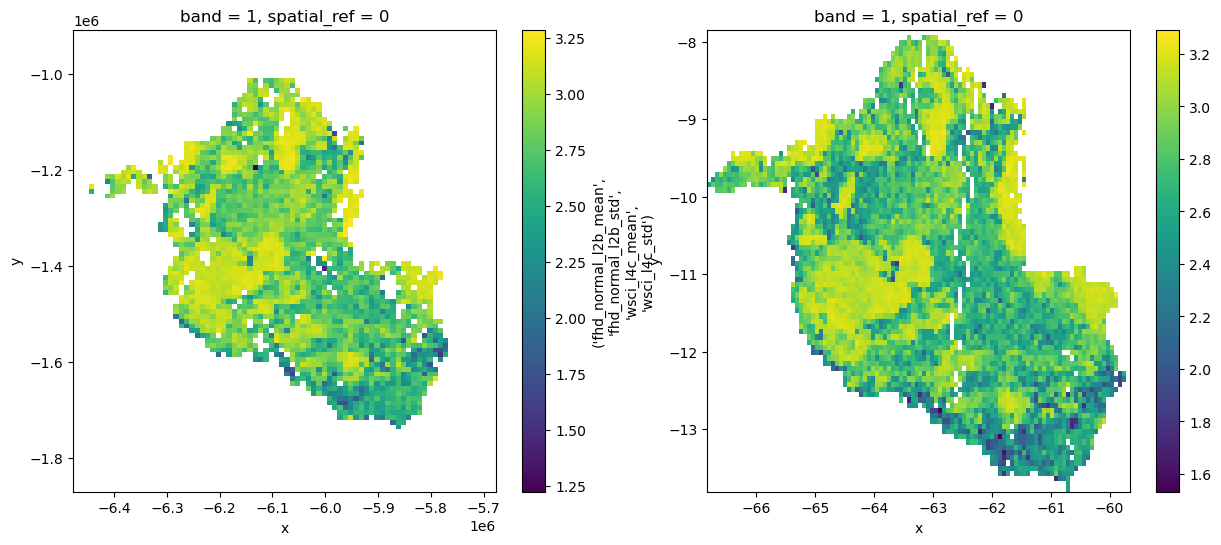

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
img_03[0].plot.imshow()

plt.subplot(1,2,2)
img_05[0].plot.imshow()

In [7]:
import glob
import dask_geopandas as dkg
import matplotlib.pyplot as plt

d = '/gpfs/data1/vclgp/decontot/repos/gedih3/tmp/gh3_extract_tests/'

h3_files = glob.glob(d + 'ro_h3/*.parquet')
df_h3 = dkg.read_parquet(h3_files)
df_h3 = df_h3.sample(frac=0.1).compute()

egi_files = glob.glob(d + 'ro_egi/*.parquet')
df_egi = dkg.read_parquet(egi_files)
df_egi = df_egi.sample(frac=0.1).compute()

In [8]:
df_egi

,datetime,shot_number,land_cover_data/pft_class_l4a,fhd_normal_l2b,geometry,egi12
egi01,,,,,,
1068037100559148946,2021-05-12 17:09:42.096686602,136740600400675053,2,3.001519,POINT (-66.09378 -9.76716),12068037000000000000
1068037101743152194,2021-05-20 14:03:41.203654051,137960600400675280,2,2.000310,POINT (-66.0815 -9.74132),12068037000000000000
1068037143862150279,2022-05-24 12:05:57.040699959,195151100400264316,2,1.760509,POINT (-65.64458 -9.75655),12068037000000000000
1068037066675145464,2021-05-28 10:58:16.113492727,139181100400264385,2,2.847941,POINT (-66.44528 -9.79488),12068037000000000000
1068037157056157656,2021-05-19 01:34:09.550307035,137730600100234661,2,3.061024,POINT (-65.50772 -9.69786),12068037000000000000
...,...,...,...,...,...,...
1072036043798121011,2020-07-13 03:42:36.758919001,89690300100093035,2,2.878129,POINT (-60.04359 -11.2662),12072036000000000000
1072036002142154483,2022-02-28 08:21:31.009263754,181951100100066253,2,2.386502,POINT (-60.4757 -10.99869),12072036000000000000
1072036035469018942,2021-08-19 12:32:05.046279192,152060600100211479,2,2.930146,POINT (-60.12999 -12.08347),12072036000000000000


In [9]:
df_h3

,fhd_normal_l2b,geometry,shot_number,datetime,land_cover_data/pft_class_l4a,h3_03
h3_12,,,,,,
8c8a009a438a9ff,2.846514,POINT (-62.85287 -8.25989),150690500100059934,2021-08-10 16:24:58.655357599,2,838a00fffffffff
8c8a0086288c3ff,2.801584,POINT (-63.08208 -8.06403),83820300400254346,2020-06-05 07:55:57.474956274,2,838a00fffffffff
8c8a0096b76e1ff,3.222025,POINT (-63.14179 -8.14974),144820800400259155,2021-07-03 20:17:24.192118883,2,838a00fffffffff
8c8a0098345b7ff,3.053391,POINT (-62.82103 -8.16133),143600300400254637,2021-06-25 23:21:28.805075884,2,838a00fffffffff
8c8a00d6c501bff,2.639393,POINT (-62.74492 -8.15043),192860500400254755,2022-05-09 17:40:41.627732515,2,838a00fffffffff
...,...,...,...,...,...,...
8c8badb71a5cbff,3.336138,POINT (-60.80788 -13.03417),160750800100066089,2021-10-14 14:21:43.601309299,4,838badfffffffff
8c8bad6056265ff,3.176833,POINT (-60.13902 -12.51654),155950800400262695,2021-09-13 15:55:16.333871841,2,838badfffffffff
8c8bad75cdb5bff,2.816455,POINT (-60.23133 -12.55814),150840100100066366,2021-08-11 15:37:10.651257277,6,838badfffffffff


<Axes: >

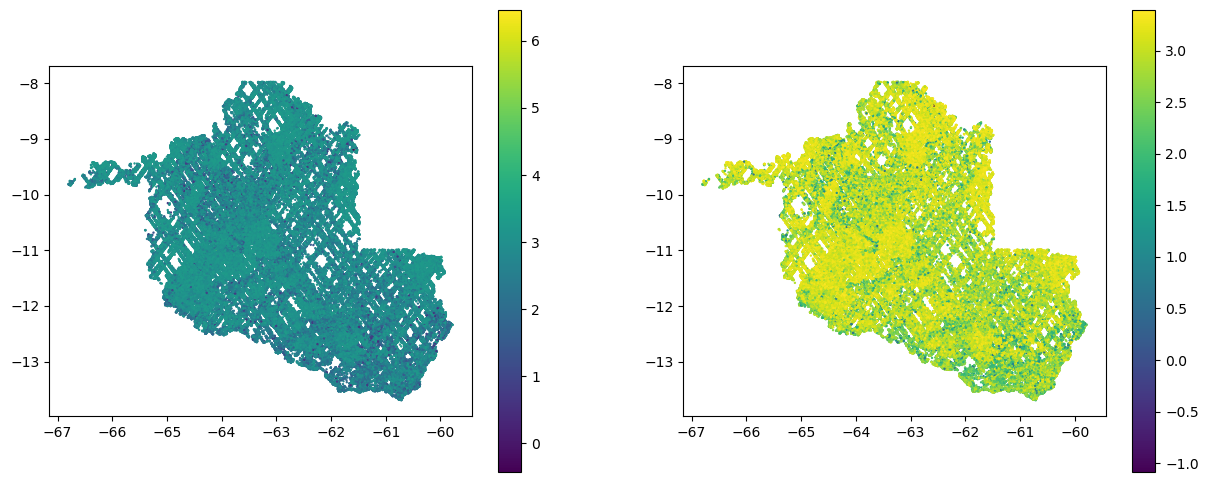

In [10]:
plt.figure(figsize=(15, 6))

ax = plt.subplot(1, 2, 1)
df_h3.plot(column='fhd_normal_l2b', ax=ax, legend=True, cmap='viridis', markersize=.5)

ax = plt.subplot(1, 2, 2)
df_egi.plot(column='fhd_normal_l2b', ax=ax, legend=True, cmap='viridis', markersize=.5)

In [91]:
ipath = '/gpfs/data1/vclgp/decontot/repos/gedih3/tmp/gh3_extract_tests/ro_h3'
opath = '/gpfs/data1/vclgp/decontot/repos/gedih3/tmp/gh3_aggregate_tests/ro_h3'

!gh3_aggregate -d $ipath -o $opath -h3 6 -a "['mean','median','std','p50']" -l fhd_normal_l2b -vv

2026-02-09 20:00:13 [INFO] gedih3.cli.gh3_aggregate: 
2026-02-09 20:00:13 [INFO] gedih3.cli.gh3_aggregate: ======================================================================
2026-02-09 20:00:13 [INFO] gedih3.cli.gh3_aggregate:                      GEDI H3 Data Aggregation Tool                    
2026-02-09 20:00:13 [INFO] gedih3.cli.gh3_aggregate:                              gedih3 v0.0.1                            
2026-02-09 20:00:13 [INFO] gedih3.cli.gh3_aggregate: ======================================================================
2026-02-09 20:00:13 [INFO] gedih3.cli.gh3_aggregate: 
2026-02-09 20:00:13 [INFO] gedih3.cli.gh3_aggregate: Database: /gpfs/data1/vclgp/decontot/repos/gedih3/tmp/gh3_extract_tests/ro_h3
2026-02-09 20:00:13 [INFO] gedih3.cli.gh3_aggregate:   Source: simplified_dataset (h3 index)
2026-02-09 20:00:13 [INFO] gedih3.cli.gh3_aggregate: Collecting variables...
2026-02-09 20:00:13 [INFO] gedih3.cli.gh3_aggregate:   Total variables: 1
2026-02-09 20:00:13 [

In [113]:
ipath = '/gpfs/data1/vclgp/decontot/repos/gedih3/tmp/gh3_extract_tests/ro_h3'
opath = '/gpfs/data1/vclgp/decontot/repos/gedih3/tmp/gh3_aggregate_tests/ro_h3_ts'

!gh3_aggregate -d $ipath -o $opath -h3 6 -a "['mean','median','std','p50','count']" -l fhd_normal_l2b -vv -ti 6 -tu months -t0 2020-01-01 -t1 2022-06-01

2026-02-09 20:18:52 [INFO] gedih3.cli.gh3_aggregate: 
2026-02-09 20:18:52 [INFO] gedih3.cli.gh3_aggregate: ======================================================================
2026-02-09 20:18:52 [INFO] gedih3.cli.gh3_aggregate:                      GEDI H3 Data Aggregation Tool                    
2026-02-09 20:18:52 [INFO] gedih3.cli.gh3_aggregate:                              gedih3 v0.0.1                            
2026-02-09 20:18:52 [INFO] gedih3.cli.gh3_aggregate: ======================================================================
2026-02-09 20:18:52 [INFO] gedih3.cli.gh3_aggregate: 
2026-02-09 20:18:52 [INFO] gedih3.cli.gh3_aggregate: Database: /gpfs/data1/vclgp/decontot/repos/gedih3/tmp/gh3_extract_tests/ro_h3
2026-02-09 20:18:52 [INFO] gedih3.cli.gh3_aggregate:   Source: simplified_dataset (h3 index)
2026-02-09 20:18:52 [INFO] gedih3.cli.gh3_aggregate: Collecting variables...
2026-02-09 20:18:52 [INFO] gedih3.cli.gh3_aggregate:   Total variables: 2
2026-02-09 20:18:52 [

In [120]:
import dask.dataframe as dd
h3_files = glob.glob(opath + '/2021-07-01-to-2022-01-01/*.parquet')
df = dkg.read_parquet(h3_files).compute()
df

,fhd_normal_l2b_mean,fhd_normal_l2b_median,fhd_normal_l2b_std,fhd_normal_l2b_p50,fhd_normal_l2b_count,geometry
h3_06,,,,,,
868a2c507ffffff,3.041512,3.041512,NaN,3.041512,1,"POLYGON ((-65.25787 -9.26503, -65.28453 -9.286..."
868a2c527ffffff,3.185212,3.235882,0.185000,3.235882,378,"POLYGON ((-65.28008 -9.32087, -65.30675 -9.342..."
868a2c52fffffff,3.142375,3.245366,0.318840,3.245366,346,"POLYGON ((-65.31564 -9.27265, -65.34232 -9.293..."
868a2c537ffffff,3.238760,3.238760,NaN,3.238760,1,"POLYGON ((-65.22233 -9.31323, -65.24897 -9.334..."
868a2c807ffffff,3.179352,3.221102,0.136882,3.221102,137,"POLYGON ((-65.81088 -9.54985, -65.83776 -9.571..."
...,...,...,...,...,...,...
868badb87ffffff,2.592747,2.551538,0.447059,2.551538,291,"POLYGON ((-60.54347 -13.05967, -60.51704 -13.0..."
868badb8fffffff,2.348983,2.423733,0.301894,2.423733,13,"POLYGON ((-60.57959 -13.01145, -60.55316 -12.9..."
868badb9fffffff,2.620992,2.678668,0.491663,2.678668,376,"POLYGON ((-60.52189 -13.00561, -60.49545 -12.9..."


<Axes: >

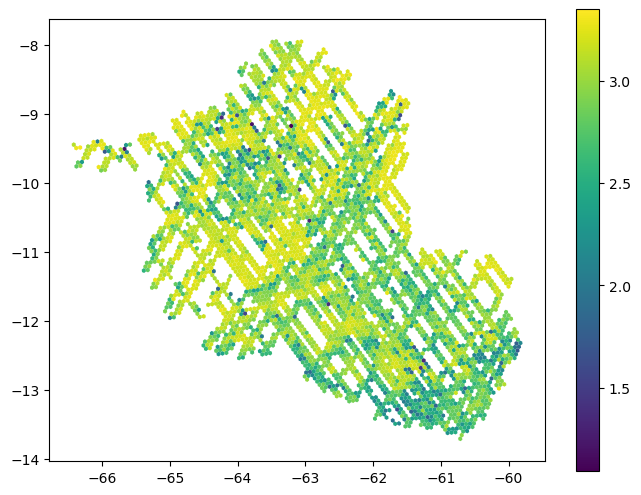

In [121]:
plt.figure(figsize=(8, 6))

ax = plt.subplot(1, 1, 1)
df.plot(column='fhd_normal_l2b_p50', ax=ax, legend=True, cmap='viridis', markersize=.5)

In [122]:
ipath = '/gpfs/data1/vclgp/decontot/repos/gedih3/tmp/gh3_extract_tests/ro_egi'
opath = '/gpfs/data1/vclgp/decontot/repos/gedih3/tmp/gh3_aggregate_tests/ro_egi_ts'

!gh3_aggregate -d $ipath -o $opath -egi 8 -a "['mean','median','std','count','p25']" -l fhd_normal_l2b -ti 6 -tu months -t0 2020-01-01 -t1 2022-06-01


                    GEDI EGI Data Aggregation Tool                    
                             gedih3 v0.0.1                            

Database: /gpfs/data1/vclgp/decontot/repos/gedih3/tmp/gh3_extract_tests/ro_egi
  Source: simplified_dataset (egi index)
  Total variables: 3
Query filter: datetime >= '2020-01-01' & datetime <= '2022-06-01'
Aggregation: ['mean', 'median', 'std', 'count', <function _make_percentile_func.<locals>.percentile_func at 0x150f03734360>]
Dask dashboard: http://127.0.0.1:8787/status
  Target: EGI level 8 (~10009m pixels)
  Partition: EGI level 12 (~160143m)
Time-series mode: 6 months from 2020-01-01 to 2022-06-01
Loading data...
  Source: simplified dataset
  Loaded 19 partitions
── Window: 2020-01-01-to-2020-07-01 ──###] | 100% Completed |  8.1s
Aggregating to EGI (shuffle-based)...
  Result: 19 EGI partitions
  Dropping internal columns: ['egi12']
Exporting data...########################] | 100% Completed |  5.3s
  Output format: simplified flat file

In [123]:
ipath = '/gpfs/data1/vclgp/decontot/repos/gedih3/tmp/gh3_extract_tests/ro_egi'
opath = '/gpfs/data1/vclgp/decontot/repos/gedih3/tmp/gh3_aggregate_tests/ro_egi_ras_ts'

!gh3_aggregate -d $ipath -o $opath -egi 8 -a "['mean','median','std','count','p25']" -l fhd_normal_l2b -ti 6 -tu months -t0 2020-01-01 -t1 2022-06-01 -R 


                    GEDI EGI Data Aggregation Tool                    
                             gedih3 v0.0.1                            

Database: /gpfs/data1/vclgp/decontot/repos/gedih3/tmp/gh3_extract_tests/ro_egi
  Source: simplified_dataset (egi index)
  Total variables: 3
Query filter: datetime >= '2020-01-01' & datetime <= '2022-06-01'
Aggregation: ['mean', 'median', 'std', 'count', <function _make_percentile_func.<locals>.percentile_func at 0x14b5eb32c2c0>]
Dask dashboard: http://127.0.0.1:8787/status
  Target: EGI level 8 (~10009m pixels)
  Partition: EGI level 12 (~160143m)
Time-series mode: 6 months from 2020-01-01 to 2022-06-01
Loading data...
  Source: simplified dataset
  Loaded 19 partitions
── Window: 2020-01-01-to-2020-07-01 ──###] | 100% Completed |  7.8s
Aggregating to EGI (shuffle-based)...
  Result: 19 EGI partitions
  Dropping internal columns: ['egi12']
Rasterizing aggregated data to GeoTIFF...] | 100% Completed | 17.1s
Warning 1: Can't open /gpfs/data1/vcl

In [126]:
import rioxarray
img = rioxarray.open_rasterio(opath + '/2020-01-01-to-2020-07-01/mosaic.vrt')
img

<xarray.DataArray (band: 5, y: 96, x: 80)> Size: 154kB
[38400 values with dtype=float32]
Coordinates:
  * band         (band) int64 40B 1 2 3 4 5
  * x            (x) float64 640B -6.473e+06 -6.463e+06 ... -5.682e+06
  * y            (y) float64 768B -9.138e+05 -9.238e+05 ... -1.865e+06
    spatial_ref  int64 8B 0
Attributes:
    _FillValue:    nan
    scale_factor:  1.0
    add_offset:    0.0

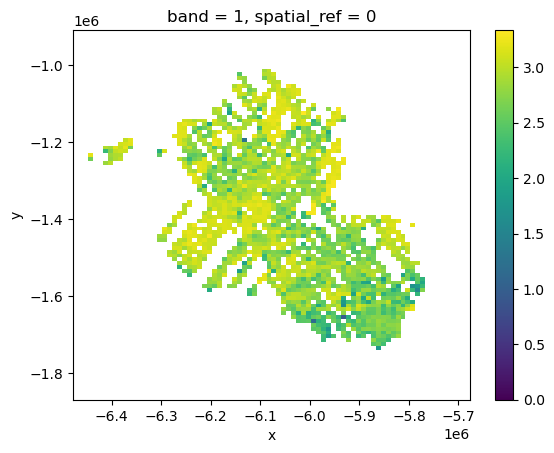

In [127]:
img[0].plot.imshow(vmin=0)

In [95]:
import dask.dataframe as dd
h3_files = glob.glob(opath + '/*.parquet')
df = dkg.read_parquet(opath).compute()
df

,fhd_normal_l2b_mean,fhd_normal_l2b_median,fhd_normal_l2b_std,fhd_normal_l2b_count,fhd_normal_l2b_p25,geometry
egi08,,,,,,
8068037000003000014,2.729425,2.869071,0.494731,598,2.364764,"POLYGON ((-6437756.79 -1249116.989, -6437756.7..."
8068037000003000015,3.166997,3.196439,0.138547,22,3.081149,"POLYGON ((-6437756.79 -1239108.039, -6437756.7..."
8068037000004000014,2.855755,3.137226,0.547018,18,2.690157,"POLYGON ((-6427747.84 -1249116.989, -6427747.8..."
8068037000004000015,2.738810,3.141264,0.742474,71,2.329988,"POLYGON ((-6427747.84 -1239108.039, -6427747.8..."
8068037000005000015,2.772380,2.893239,0.608112,54,2.632652,"POLYGON ((-6417738.89 -1239108.039, -6417738.8..."
...,...,...,...,...,...,...
8072036000005000009,3.139160,3.149975,0.125815,13,3.065660,"POLYGON ((-5777166.075 -1459304.944, -5777166...."
8072036000005000010,3.085636,3.148487,0.253310,548,2.987700,"POLYGON ((-5777166.075 -1449295.994, -5777166...."
8072036000005000011,3.133211,3.180662,0.198000,239,3.066959,"POLYGON ((-5777166.075 -1439287.044, -5777166...."


<Axes: >

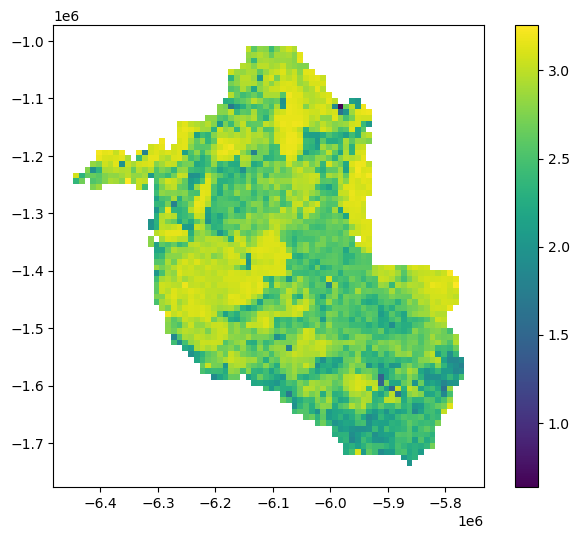

In [96]:
plt.figure(figsize=(8, 6))

ax = plt.subplot(1, 1, 1)
df.plot(column='fhd_normal_l2b_p25', ax=ax, legend=True, cmap='viridis', markersize=.5)

## Standalone gh3_rasterize Tests

Test `gh3_rasterize` on pre-aggregated datasets (from `gh3_aggregate`).

In [ ]:
# Rasterize pre-aggregated EGI dataset (tiled output)
egi_agg = '/gpfs/data1/vclgp/decontot/repos/gedih3/tmp/gh3_aggregate_tests/ro_egi_ts/2021-01-01-to-2021-07-01'
raster_out = '/gpfs/data1/vclgp/decontot/repos/gedih3/tmp/gh3_rasterize_tests/egi_tiled'

!gh3_rasterize -d $egi_agg -o $raster_out -v

In [ ]:
# Rasterize time-series directory (auto-detects subdirectories)
ts_agg = '/gpfs/data1/vclgp/decontot/repos/gedih3/tmp/gh3_aggregate_tests/ro_egi_ts'
raster_ts_out = '/gpfs/data1/vclgp/decontot/repos/gedih3/tmp/gh3_rasterize_tests/egi_timeseries'

!gh3_rasterize -d $ts_agg -o $raster_ts_out -v

In [ ]:
# Merged rasterize from pre-aggregated EGI dataset
egi_agg = '/gpfs/data1/vclgp/decontot/repos/gedih3/tmp/gh3_aggregate_tests/ro_egi_ts/2021-01-01-to-2021-07-01'
raster_merged = '/gpfs/data1/vclgp/decontot/repos/gedih3/tmp/gh3_rasterize_tests/egi_merged.tif'

!gh3_rasterize -d $egi_agg -m -o $raster_merged -v

In [ ]:
import gedih3 as gh3
tmp = '//gpfs/data1/vclgp/data/iss_gedi/h3_mock/tmp/duckdb'
ddb = gh3.sqlutils.init_duckdb(temp_directory=tmp)

In [ ]:
def data_spec(hex_id=None, year=None):
    db_path = '/gpfs/data1/vclgp/data/iss_gedi/h3_mock/database'
    h3_part = "*"
    year_part = "*"
    if hex_id is not None:
        h3_part = f"{hex_id}"
    if year is not None:
        year_part = f"year={year}"
    return f"{db_path}/{h3_part}/{year_part}/*.parquet"

In [ ]:
ddb.sql(f"""
    SELECT *
    FROM read_parquet('{data_spec()}')
    WHERE  {q}
    LIMIT 10
""")